<h1> Exploratory Data Analysis (EDA) </h1>

This notebook works with the raw Titanic data rather than the scaled or encoded version, because the goal of EDA is to understand the data itself and the relationships between the variables.

#### Exploratory Data Analysis — Titanic Dataset

1. Load Dataset
2. Dataset Overview
3. Target Distribution
4. Numerical Feature Analysis
5. Categorical Feature Analysis
6. Missing Data Analysis
7. Relationship Between Features and Target
8. Correlation Analysis
9. Outlier Analysis
10. Key Findings

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

<h3> Step 1: Dataset Loading </h3>

In [2]:
dataset_path = "../../datasets/Titanic-Dataset/raw/Titanic-Dataset.csv"

df = pd.read_csv(dataset_path)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<h3> Step 2: Dataset Overview </h3>

In [3]:
print("Shape:", df.shape)
print()

df.info()

Shape: (891, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


<h3> Step 3: Target Distribution </h3>

In [5]:
survival_counts = df["Survived"].value_counts()

survival_counts

Survived
0    549
1    342
Name: count, dtype: int64

In [6]:
df["Survived"].value_counts(
    normalize=True
)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

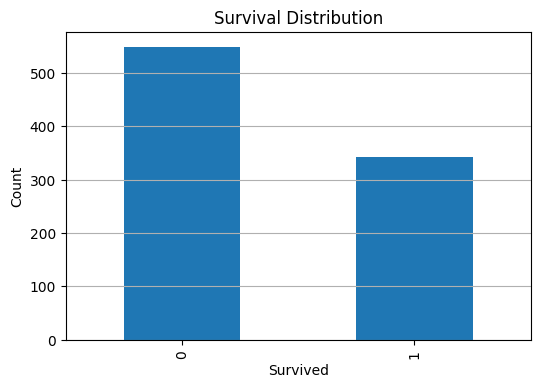

In [7]:
plt.figure(figsize=(6, 4))

df["Survived"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Survival Distribution")
plt.grid(axis="y")
plt.show()

<h3> Step 4: Numerical Features </h3>

In [8]:
numerical_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

Here, we are looking for:

skewness</br>
unusual values</br>
outliers</br>
distribution shape

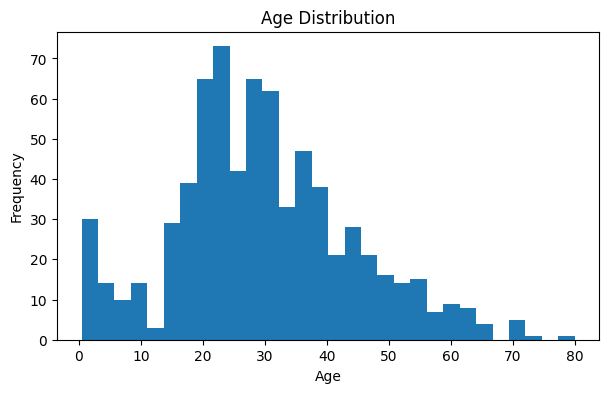

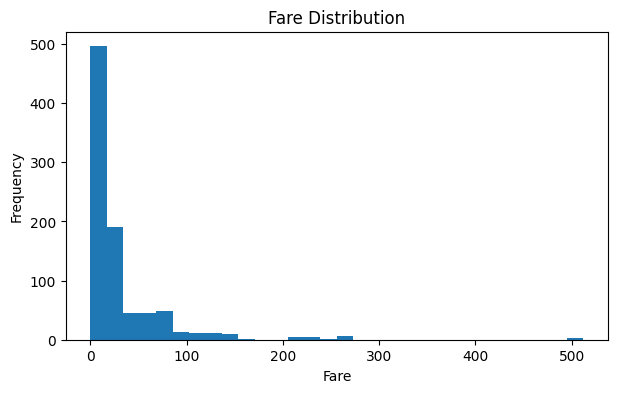

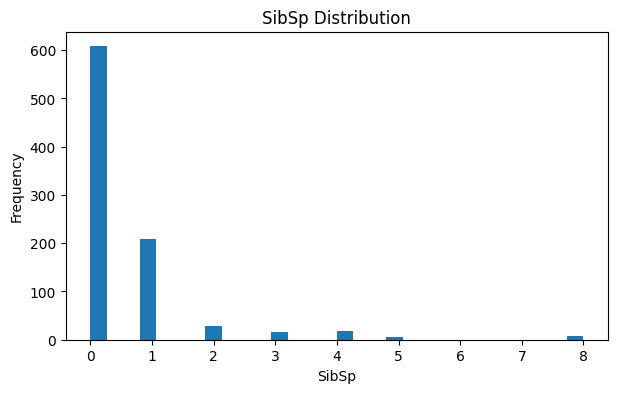

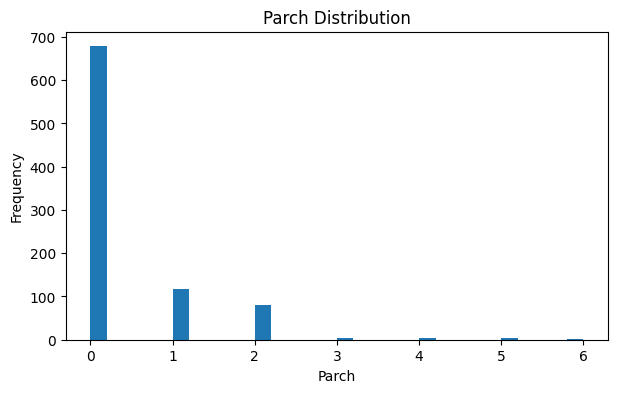

In [9]:
for feature in numerical_features:

    plt.figure(figsize=(7, 4))

    df[feature].dropna().hist(
        bins=30
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"{feature} Distribution")
    plt.grid()

    plt.show()

Age shows a relatively concentrated distribution around young and middle-aged passengers.
The presence of children and elderly passengers indicates that the dataset contains
a diverse age range. Missing values in Age require appropriate imputation during
preprocessing.

Fare is highly right-skewed, with most passengers paying relatively low fares
and a small number of passengers having very high fares. These extreme values
should be considered during modeling and feature analysis.

Most passengers traveled alone or with a small number of family members.

Both SibSp and Parch are highly concentrated around zero, indicating that most
passengers traveled without many family members.

<h3> Step 5: Categorical Features </h3>

Cabin contains a large number of missing values.
Although it was removed in the initial preprocessing stage,
it may contain useful information through feature extraction,
such as deck identification. This will be investigated in
the Feature Engineering stage.

The Name feature contains title information that may provide
predictive value. Extracting titles will be considered during
feature engineering.

In [10]:
categorical_features = [
    "Sex",
    "Pclass",
    "Embarked"
]

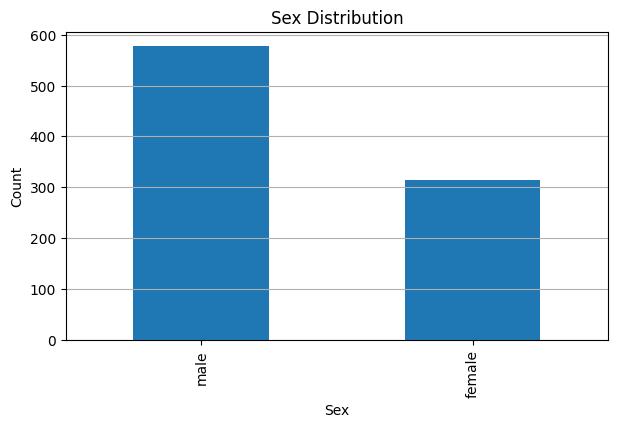

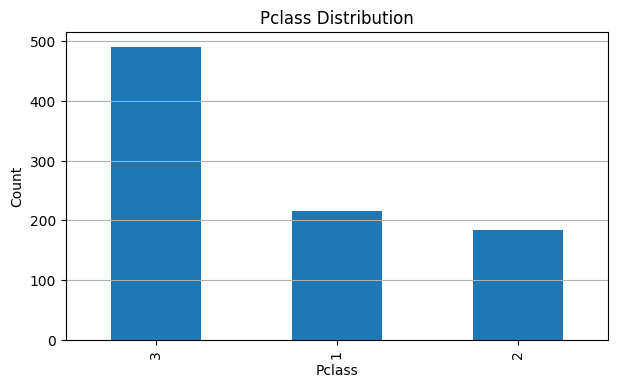

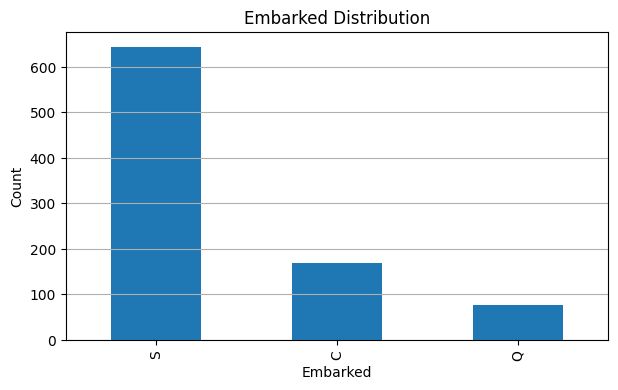

In [11]:
for feature in categorical_features:

    plt.figure(figsize=(7, 4))

    df[feature].value_counts().plot(
        kind="bar"
    )

    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(f"{feature} Distribution")
    plt.grid(axis="y")

    plt.show()

The number of men is approximately double that of women. The dataset is not perfectly balanced in terms of gender, but the imbalance is not severe.

Passenger class distribution is imbalanced, with a larger proportion of passengers
belonging to the third class.

The Embarked feature is dominated by Southampton (S), while other embarkation
points represent smaller groups.

<h3> Step 6: Missing Values </h3>

In [12]:
missing_values = df.isnull().sum()

missing_values[
    missing_values > 0
].sort_values(
    ascending=False
)

Cabin       687
Age         177
Embarked      2
dtype: int64

In [13]:
missing_percentage = (
    df.isnull().mean() * 100
)

missing_percentage[
    missing_percentage > 0
].sort_values(
    ascending=False
)

Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64

<h3> Step 7: Relationship with Target </h3>

This is where the most important part of EDA begins.

Step 7.1: Sex vs Survival

In [14]:
sex_survival = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
)

sex_survival

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


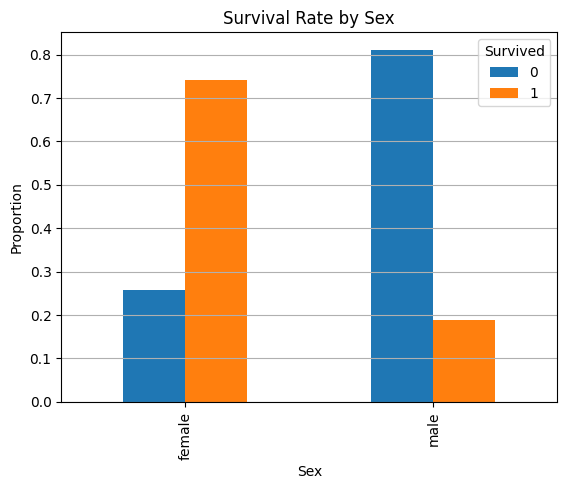

In [15]:
sex_survival.plot(
    kind="bar"
)

plt.ylabel("Proportion")
plt.title("Survival Rate by Sex")
plt.grid(axis="y")
plt.show()

Survival rate differs substantially between genders. Female passengers have a
considerably higher survival proportion compared with male passengers, suggesting
that Sex is likely an important predictive feature.

Step 7.2: Passenger Class vs Survival

In [16]:
pclass_survival = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
)

pclass_survival

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


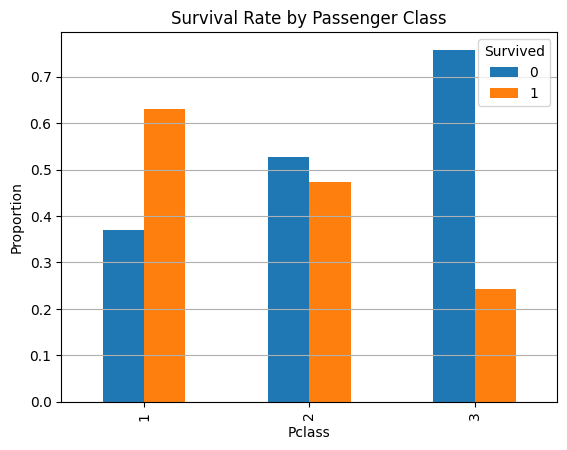

In [17]:
pclass_survival.plot(
    kind="bar"
)

plt.ylabel("Proportion")
plt.title("Survival Rate by Passenger Class")
plt.grid(axis="y")
plt.show()

Passenger class appears to be associated with survival probability. Higher-class
passengers generally show higher survival rates compared with lower-class
passengers.

Step 7.3: Embarked vs Survival

In [18]:
embarked_survival = pd.crosstab(
    df["Embarked"],
    df["Survived"],
    normalize="index"
)

embarked_survival

Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


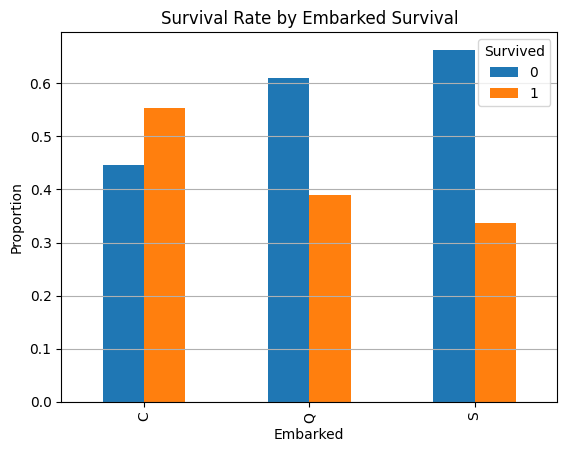

In [19]:
embarked_survival.plot(
    kind="bar"
)

plt.ylabel("Proportion")
plt.title("Survival Rate by Embarked Survival")
plt.grid(axis="y")
plt.show()

Category C has a slightly higher survival rate. Category S has the highest count, but the survival rate is lower. However, we must be cautious, as 'Embarked' might have an indirect effect and could also be correlated with 'Pclass'.

Step 7.4: Age vs Survival

For numerical data, it is better to look at the averages.

In [20]:
df.groupby(
    "Survived"
)["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

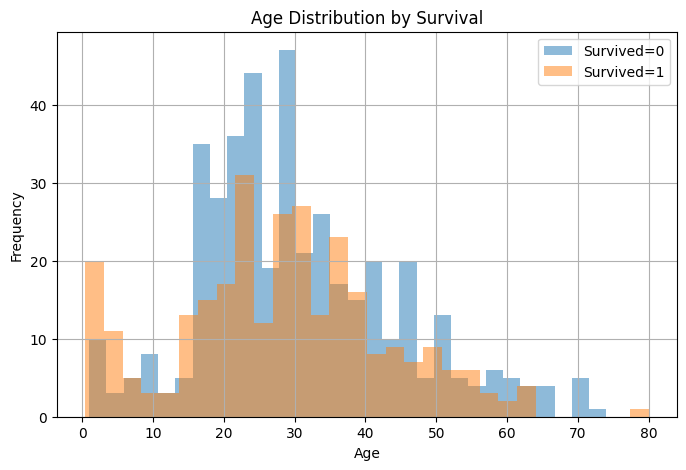

In [21]:
plt.figure(figsize=(8, 5))

for survived in [0, 1]:

    df.loc[
        df["Survived"] == survived,
        "Age"
    ].dropna().hist(
        bins=30,
        alpha=0.5,
        label=f"Survived={survived}"
    )

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution by Survival")
plt.legend()
plt.show()

Age alone does not show a strong separation between survivors and non-survivors.
However, it may provide additional predictive information when combined with
other features.

Step 7.5: Fare vs Survival

In [22]:
df.groupby(
    "Survived"
)["Fare"].median()

Survived
0    10.5
1    26.0
Name: Fare, dtype: float64

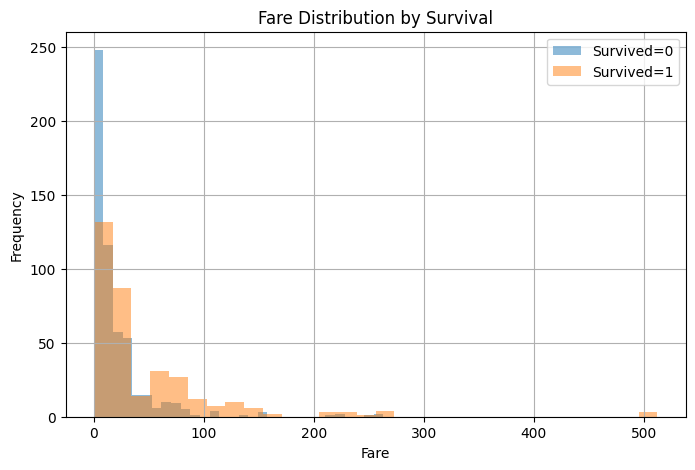

In [23]:
plt.figure(figsize=(8, 5))

for survived in [0, 1]:

    df.loc[
        df["Survived"] == survived,
        "Fare"
    ].dropna().hist(
        bins=30,
        alpha=0.5,
        label=f"Survived={survived}"
    )

plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Distribution by Survival")
plt.legend()
plt.show()

Higher fares appear to be associated with increased survival probability.
This relationship may partially reflect the effect of passenger class.

<h3> Step 8: Correlation </h3>

In [24]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = (
    numeric_df.corr()
)

correlation_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


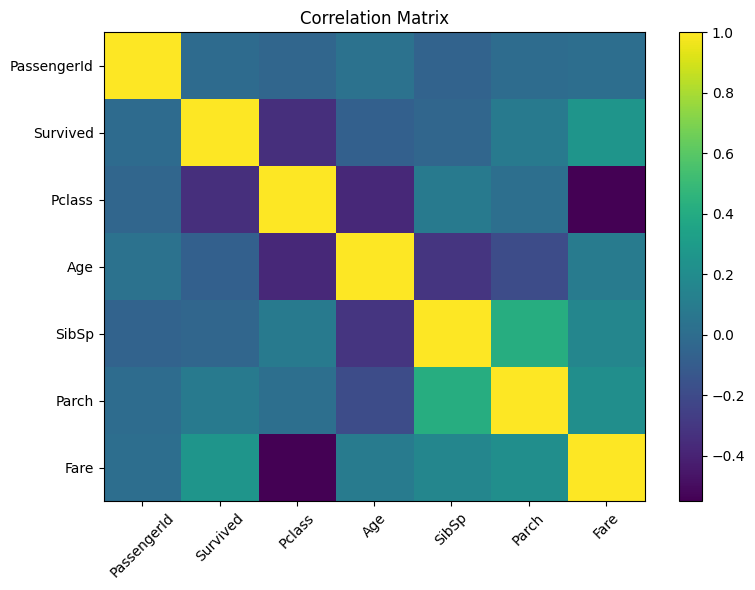

In [25]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

Survived Correlation:

Positive with Fare</br>
Negative with Pclass

means:

Higher fare → more chance of survival</br>
Higher Pclass number (lower class) → lower probability of survival

But:</br>
Correlation shows only linear relationship.

<h3> Step 9: Outlier Analysis </h3>

Fare

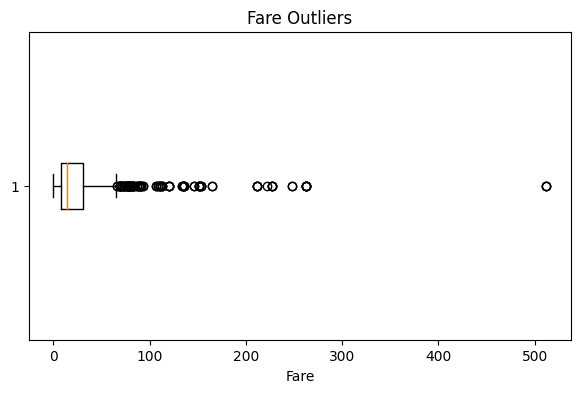

In [26]:
plt.figure(figsize=(7, 4))

plt.boxplot(
    df["Fare"].dropna(),
    vert=False
)

plt.xlabel("Fare")
plt.title("Fare Outliers")

plt.show()

The most obvious outliers:

Many values ​​outside the IQR range Very high values

However:</br>
We should not remove them blindly.

Because:
High fare ≠ Error</br>

It may provide important information regarding passenger class.

Age

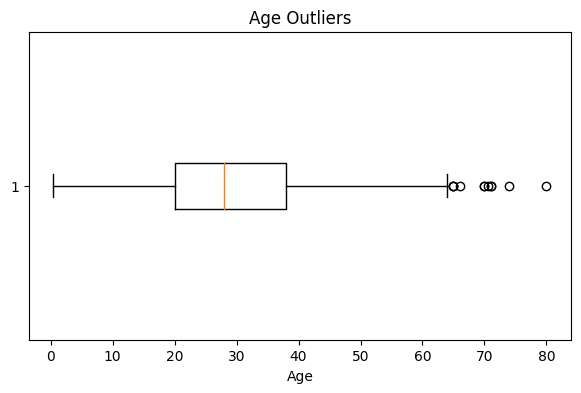

In [27]:
plt.figure(figsize=(7, 4))

plt.boxplot(
    df["Age"].dropna(),
    vert=False
)

plt.xlabel("Age")
plt.title("Age Outliers")

plt.show()

There are a few outliers above the age of 65; however, in a real-world dataset, these are valid values.

## Statistical Analysis in EDA

<h3> Step 10: Chi-square test For categorical variables </h3>

Objective:

To examine whether there is a significant relationship between categorical variables and Survival.

Variables:
1. Sex
2. Pclass
3. Embarked

In [29]:
def chi_square_test(
    feature,
    target="Survived"
):

    contingency_table = pd.crosstab(
        df[feature],
        df[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    print(f"Feature: {feature}")
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < 0.05:
        print(
            "Result: Significant relationship"
        )
    else:
        print(
            "Result: No significant relationship"
        )

    print("-"*40)

In [30]:
chi_square_test("Sex")
chi_square_test("Pclass")
chi_square_test("Embarked")

Feature: Sex
Chi-square statistic: 260.7170
p-value: 0.000000
Result: Significant relationship
----------------------------------------
Feature: Pclass
Chi-square statistic: 102.8890
p-value: 0.000000
Result: Significant relationship
----------------------------------------
Feature: Embarked
Chi-square statistic: 26.4891
p-value: 0.000002
Result: Significant relationship
----------------------------------------


#### Chi-Square Test Results

Chi-square tests were performed to evaluate the association between
categorical variables and survival outcome.

The results showed statistically significant relationships between
Survived and all investigated categorical features.

Sex demonstrated the strongest association with survival, indicating
substantial differences in survival distribution between male and female
passengers.

Passenger class also showed a significant relationship with survival,
suggesting that class-related factors influenced survival patterns.

Embarked showed a statistically significant association as well, although
this relationship may be influenced by other correlated variables such as
passenger class and fare.

These results are consistent with the observations from exploratory
visualizations and suggest that Sex and Pclass are potentially important
predictive features.

<h3> Step 11: Numerical Feature Statistical Test </h3>

Mann Whitney Test

In [32]:
def mann_whitney_test(
    feature,
    target="Survived"
):

    group_0 = df[
        df[target] == 0
    ][feature].dropna()


    group_1 = df[
        df[target] == 1
    ][feature].dropna()


    statistic, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    print(f"Feature: {feature}")
    print(f"U statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.6f}")


    if p_value < 0.05:
        print(
            "Result: Significant difference"
        )
    else:
        print(
            "Result: No significant difference"
        )

    print("-"*40)

In [33]:
mann_whitney_test("Age")
mann_whitney_test("Fare")
mann_whitney_test("SibSp")
mann_whitney_test("Parch")

Feature: Age
U statistic: 65278.0000
p-value: 0.160493
Result: No significant difference
----------------------------------------
Feature: Fare
U statistic: 57806.5000
p-value: 0.000000
Result: Significant difference
----------------------------------------
Feature: SibSp
U statistic: 85775.0000
p-value: 0.008017
Result: Significant difference
----------------------------------------
Feature: Parch
U statistic: 82385.0000
p-value: 0.000037
Result: Significant difference
----------------------------------------


| Feature | Test           | p-value  | Result                    |
| ------- | -------------- | -------- | ------------------------- |
| Age     | Mann-Whitney U | 0.160493 | No significant difference |
| Fare    | Mann-Whitney U | <0.001   | Significant difference    |
| SibSp   | Mann-Whitney U | 0.008017 | Significant difference    |
| Parch   | Mann-Whitney U | <0.001   | Significant difference    |


#### Numerical Feature Statistical Analysis

Mann-Whitney U tests were conducted to evaluate whether numerical
features had different distributions between survived and non-survived
passengers.

The results showed that Fare, SibSp, and Parch have statistically
significant differences between the two survival groups.

Fare demonstrated a strong difference, which is consistent with the
observed relationship between passenger class, socioeconomic status,
and survival probability.

Age did not show a statistically significant difference between the two
groups, suggesting that age alone may provide limited predictive power.
However, it may still contribute useful information when combined with
other features.

The significant results for SibSp and Parch suggest that family-related
information may contain predictive value, motivating additional feature
engineering steps such as creating family size and traveling-alone
features.